In [1]:
import os
import pandas as pd
from deepmreye import analyse, architecture, preprocess, train
from deepmreye.util import data_generator, model_opts, util
import pickle
import numpy as np
import matplotlib.pyplot as plt

2025-11-13 10:22:19.770281: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-13 10:22:20.035225: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-13 10:22:20.035323: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-13 10:22:20.047829: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-13 10:22:20.161842: I tensorflow/core/platform/cpu_feature_guar

## Preprocess nifti files using Deepmreye

In [2]:
functional_data='/mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti'
eyetracker_path='sleepybrain/eyetrackinglogfiles_converted2degree/'
eyetrackerfiles=os.listdir(eyetracker_path)
print(eyetrackerfiles)
print(os.listdir(functional_data))
print(os.listdir(os.path.join(functional_data,'sub-9001')))

['9100_eyedata_deg.csv', '9001_eyedata_deg.csv', '9007_eyedata_deg.csv', '9008_eyedata_deg.csv', '9013_eyedata_deg.csv', '9023_eyedata_deg.csv', '9025_eyedata_deg.csv', '9029_eyedata_deg.csv', '9033_eyedata_deg.csv', '9041_eyedata_deg.csv', '9048_eyedata_deg.csv', '9050_eyedata_deg.csv', '9053_eyedata_deg.csv', '9055_eyedata_deg.csv', '9057_eyedata_deg.csv', '9063_eyedata_deg.csv', '9070_eyedata_deg.csv', '9071_eyedata_deg.csv', '9074_eyedata_deg.csv', '9077_eyedata_deg.csv', '9081_eyedata_deg.csv', '9082_eyedata_deg.csv', '9083_eyedata_deg.csv', '9084_eyedata_deg.csv', '9085_eyedata_deg.csv', '9087_eyedata_deg.csv', '9088_eyedata_deg.csv', '9091_eyedata_deg.csv', '9092_eyedata_deg.csv']
['sub-9008', 'sub-9013', 'sub-9023', 'sub-9025', 'sub-9029', '9001.npz', '9001_left.npz', '9001_right.npz', '9007.npz', '9007_left.npz', '9007_right.npz', '9008.npz', '9008_left.npz', '9008_right.npz', '9013.npz', '9013_left.npz', '9013_right.npz', '9023.npz', '9023_left.npz', '9023_right.npz', '9025.n

In [ ]:
functional_data = '/mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti'

# Get participants from functional folder

participants = os.listdir(functional_data)
participants.sort()

# Preload masks to save time within participant loop
(
    eyemask_small,
    eyemask_big,
    dme_template,
    mask,
    x_edges,
    y_edges,
    z_edges,
) = preprocess.get_masks()

# Loop across participants and extract eye mask
for participant in participants:
    if participant.startswith("s"):
        print("Running participant {}".format(participant))
        participant_folder = os.path.join(functional_data, participant)
        #print(participant_folder)
        for run in os.listdir(participant_folder):
            
            #Filepath to functional
            fp_func = os.path.join(participant_folder, run)
            print(fp_func)
            preprocess.run_participant(
                fp_func,
                dme_template,
                eyemask_big,
                eyemask_small,
                x_edges,
                y_edges,
                z_edges,
                transforms=['Affine', 'Affine', 'SyNAggro'] # non-linear registration
            )
           

In [168]:
def downsample_eye_data(file_path, chunk_size=0.25, group_TR=10, plot=True):
    """
    Downsample eye-tracking data into fMRI-compatible chunks (aligned overlay plot version).
    """
    import numpy as np, pandas as pd, matplotlib.pyplot as plt, os

    # --- Load and clean ---
    df = pd.read_csv(file_path)
    subj_id = str(file_path.split(os.sep)[-1][:4])
    df = df[['TotalTime', 'X_deg', 'Y_deg']].dropna()
    df = df.sort_values('TotalTime').reset_index(drop=True)
    df['RelTime'] = df['TotalTime'] - df['TotalTime'].iloc[0]

    # --- Fine binning (0.25 s) ---
    duration = df['RelTime'].max()
    fine_edges = np.arange(0, duration + chunk_size, chunk_size)
    df['FineBin'] = pd.cut(df['RelTime'], bins=fine_edges, labels=False, include_lowest=True, right=False)
    df_fine = df.groupby('FineBin', as_index=False)[['X_deg', 'Y_deg']].median()
    df_fine['Time'] = df_fine['FineBin'] * chunk_size

    # --- Coarse binning (2.5 s = 10 × 0.25 s) ---
    TR_dur = chunk_size * group_TR
    TR_edges = np.arange(0, duration + TR_dur, TR_dur)
    df['TRBin'] = pd.cut(df['RelTime'], bins=TR_edges, labels=False, include_lowest=True, right=False)
    df_TR = df.groupby('TRBin', as_index=False)[['X_deg', 'Y_deg']].median()
    df_TR['Time'] = df_TR['TRBin'] * TR_dur

    # --- Match length for 3D reshape ---
    n_chunks = len(df_fine)
    n_TRs = n_chunks // group_TR
    trimmed_len = n_TRs * group_TR
    df_fine_trim = df_fine.iloc[:trimmed_len].copy()
    df_fine_trim['TR_index'] = np.repeat(np.arange(n_TRs), group_TR)
    data_3d = df_fine_trim[['X_deg', 'Y_deg']].values.reshape(n_TRs, group_TR, 2)

    # --- Remove first 10 TRs ---
    if n_TRs > 10:
        data_3d = data_3d[10:]
        df_fine_trim = df_fine_trim[df_fine_trim['TR_index'] >= 10]
        df_TR = df_TR.iloc[10:]

    # --- Plot both with perfect alignment ---
    if plot:
        plt.figure(figsize=(10, 4))
        # fine (0.25 s)
        plt.plot(df_fine_trim['Time'], df_fine_trim['X_deg'], color='steelblue', alpha=0.4, label='X_deg (0.25 s)')
        plt.plot(df_fine_trim['Time'], df_fine_trim['Y_deg'], color='tomato', alpha=0.4, label='Y_deg (0.25 s)')
        # coarse (2.5 s)
        plt.plot(df_TR['Time'], df_TR['X_deg'], color='navy', linewidth=1.2, label='X_deg (2.5 s median)')
        plt.plot(df_TR['Time'], df_TR['Y_deg'], color='darkred', linewidth=1.2, label='Y_deg (2.5 s median)')

        plt.xlabel('Time (s)')
        plt.ylabel('Gaze Position (°)')
        plt.title(f'Subject {subj_id}: Overlapping 0.25 s and 2.5 s Gaze Time Series')
        plt.legend(fontsize=8)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    print(f"✅ Subject {subj_id}: Downsampled to {data_3d.shape[0]} TRs × {group_TR} sub-TRs × 2 coordinates")
    return data_3d, df_fine_trim, subj_id


def batch_downsample_eye_folder(folder_path):
    """
    Downsample all eye-tracking CSV files in a folder.
    
    For each subject:
      - Load file
      - Downsample based on TotalTime
      - Keep only 3D data (TRs × subTRs × [X_deg, Y_deg])
      - Store in dictionary: {subject_id: data_3d}

    Parameters
    ----------
    folder_path : str
        Folder containing CSV eye-tracking files.

    Returns
    -------
    eye_data_dict : dict
        {subject_id: np.ndarray (n_TRs, 10, 2)}
    """
    eye_data_dict = {}
    files = sorted([f for f in os.listdir(folder_path) if f.endswith('.csv')])
    print(f"🔍 Found {len(files)} files in {folder_path}\n")

    for f in files:
        file_path = os.path.join(folder_path, f)
        try:
            data_3d, _, subj_id = downsample_eye_data(file_path, plot=True)
            eye_data_dict[subj_id] = data_3d
            print(f"✅ {subj_id}: processed (shape {data_3d.shape})")
        except Exception as e:
            print(f"⚠️ {f}: failed ({e})")

    print(f"\n🎯 Finished processing {len(eye_data_dict)} subjects successfully.")
    return eye_data_dict
def merge_eye_fmri(eye_data_dict, functional_data):
    """
    Merge downsampled eye-tracking data with preprocessed fMRI data for each participant.

    Parameters
    ----------
    eye_data_dict : dict
        Dictionary {subject_id: np.ndarray (TRs, 10, 2)} from downsample_eye_data().
    functional_data : str
        Path to preprocessed fMRI data folder (each participant has a subfolder).

    Returns
    -------
    None
        Saves merged data using preprocess.save_data() for each participant.
    """

    participants = list(eye_data_dict.keys())
    print(f"🔍 Found {len(participants)} participants with eye data.\n")

    for participant in participants:

        if not participant.startswith("9"):  # adjust prefix as needed (e.g., 's' or '9')
            continue

        print(f"👁️‍🧠 Processing participant {participant}")

        participant_folder = os.path.join(functional_data, ('sub-'+ participant))
        if not os.path.exists(participant_folder):
            print(f"⚠️ Folder not found for {participant}: {participant_folder}")
            continue

        # Init containers
        participants_left, participants_right = {}, {}
        participant_data, participant_data_left, participant_data_right = [], [], []
        participant_labels = []
        participant_ids, participant_ids_left, participant_ids_right = [], [], []

        # Create left and right identifiers
        participant_left = f"{participant}_left"
        participant_right = f"{participant}_right"

        participants_left[participant] = participant_left
        participants_right[participant] = participant_right

        # Iterate over runs in the participant folder
        for run_idx, run_file in enumerate(os.listdir(participant_folder)):
            if not run_file.endswith(".p"):
                continue

            fmri_path = os.path.join(participant_folder, run_file)

            # Load and normalize mask
            this_mask = pickle.load(open(fmri_path, "rb"))
            this_mask = preprocess.normalize_img(this_mask)
            mid = this_mask.shape[0] // 2 + 1
            this_mask_left = this_mask[:mid, :, :, :]
            this_mask_right = this_mask[mid:, :, :, :]

            # Load corresponding gaze data
            gaze_data = eye_data_dict[participant]
            this_label = gaze_data  # shape (TRs, 10, 2)

            # Check alignment between fMRI TRs and gaze TRs
            if this_mask.shape[3] != this_label.shape[0]:
                print(
                    f"⚠️ Skipping {participant} Run {run_idx} — Misalignment: "
                    f"Mask {this_mask.shape} vs Label {this_label.shape}"
                )
                continue

            # Store data
            participant_data.append(this_mask)
            participant_data_left.append(this_mask_left)
            participant_data_right.append(this_mask_right)
            participant_labels.append(this_label)

            participant_ids.append(([participant] * this_label.shape[0],
                                    [run_idx] * this_label.shape[0]))
            participant_ids_left.append(([participant_left] * this_label.shape[0],
                                         [run_idx] * this_label.shape[0]))
            participant_ids_right.append(([participant_right] * this_label.shape[0],
                                          [run_idx] * this_label.shape[0]))

        # Save merged participant data
        preprocess.save_data(
            participant,
            participant_data,
            participant_labels,
            participant_ids,
            functional_data,
            center_labels=False,
        )

        preprocess.save_data(
            participant_left,
            participant_data_left,
            participant_labels,
            participant_ids_left,
            functional_data,
            center_labels=False,
        )

        preprocess.save_data(
            participant_right,
            participant_data_right,
            participant_labels,
            participant_ids_right,
            functional_data,
            center_labels=False,
        )

        print(f"✅ Saved merged data for {participant}\n")

    print("🎯 All participants processed successfully.")

🔍 Found 29 files in sleepybrain/eyetrackinglogfiles_converted2degree/



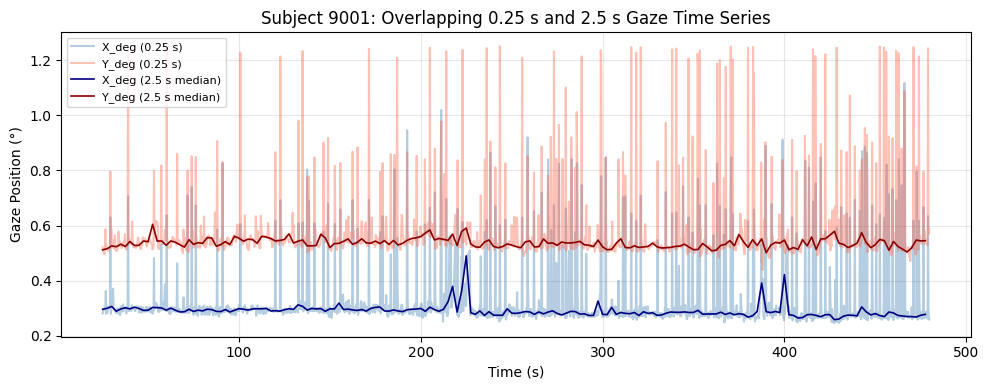

✅ Subject 9001: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9001: processed (shape (182, 10, 2))


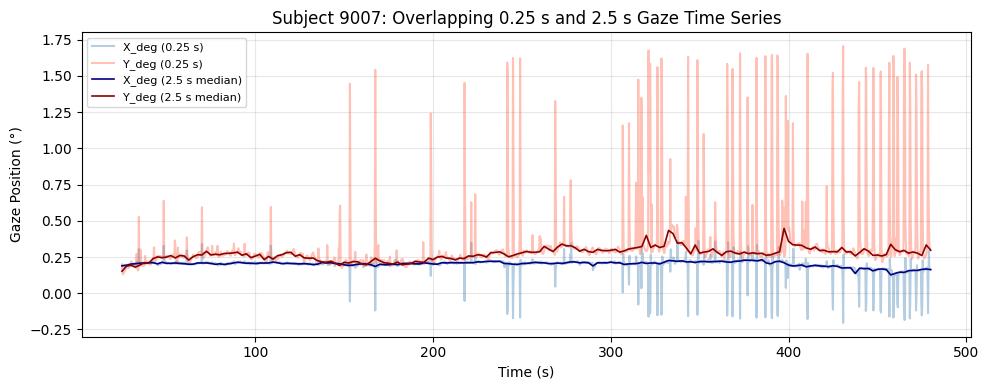

✅ Subject 9007: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9007: processed (shape (182, 10, 2))


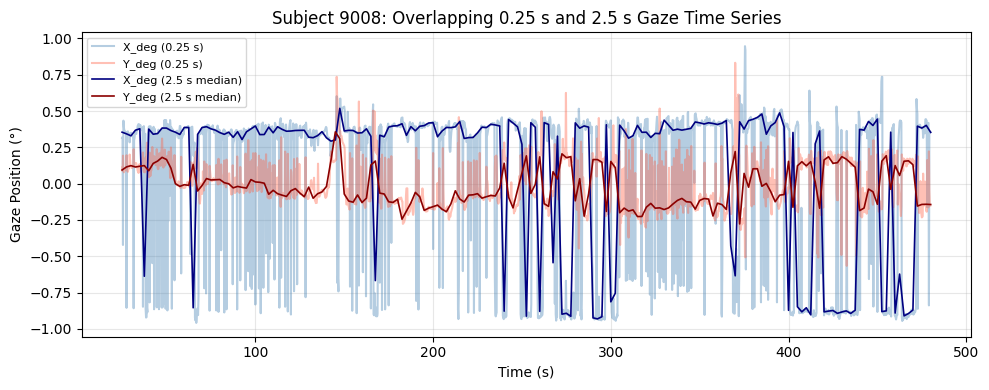

✅ Subject 9008: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9008: processed (shape (182, 10, 2))


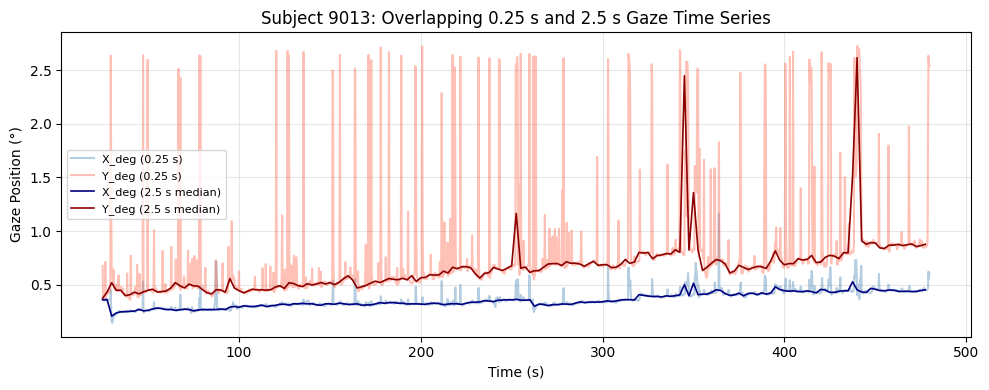

✅ Subject 9013: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9013: processed (shape (182, 10, 2))


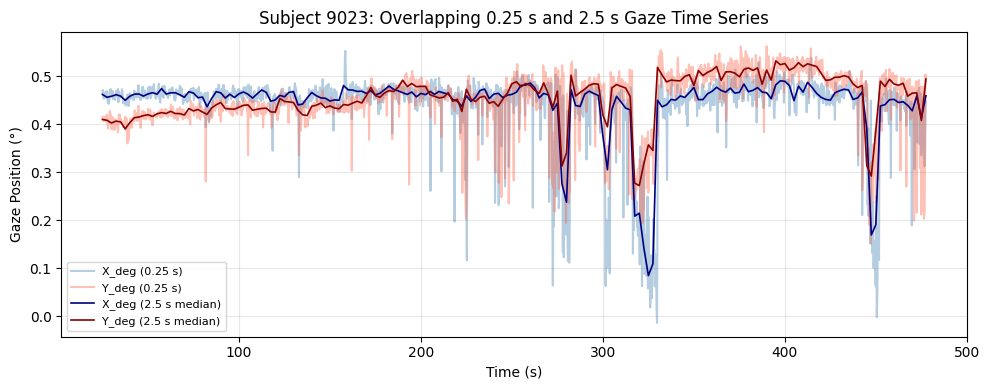

✅ Subject 9023: Downsampled to 181 TRs × 10 sub-TRs × 2 coordinates
✅ 9023: processed (shape (181, 10, 2))


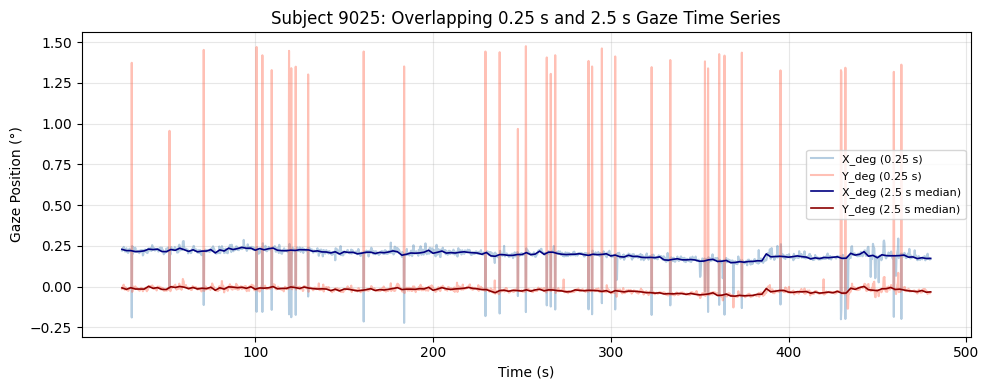

✅ Subject 9025: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9025: processed (shape (182, 10, 2))


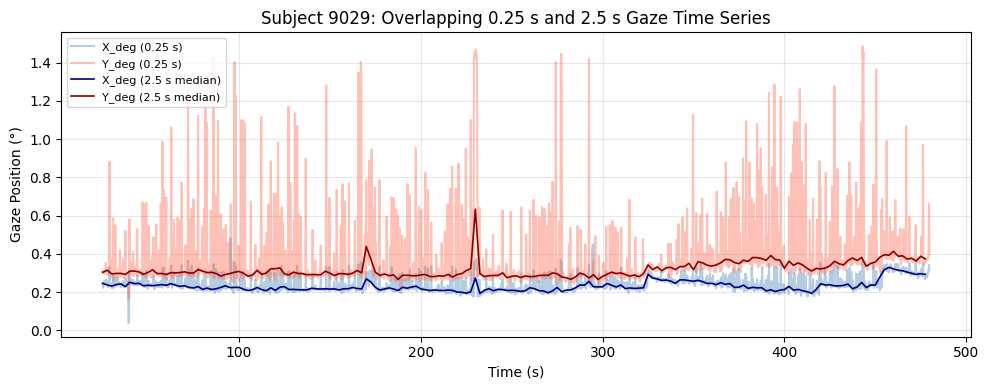

✅ Subject 9029: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9029: processed (shape (182, 10, 2))


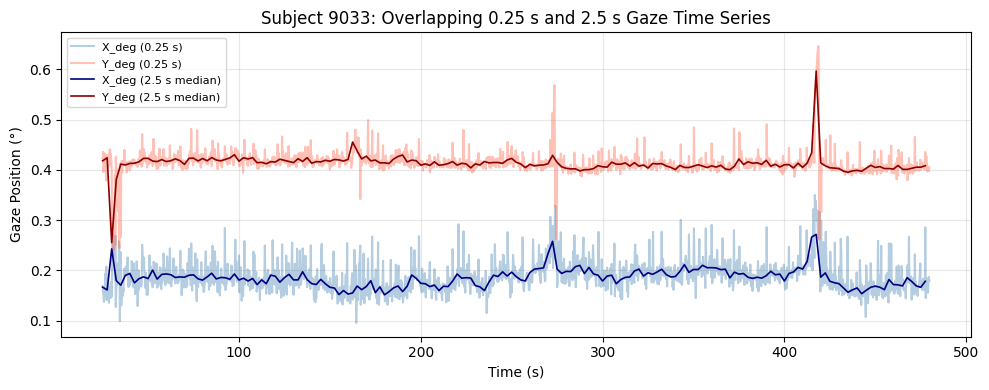

✅ Subject 9033: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9033: processed (shape (182, 10, 2))


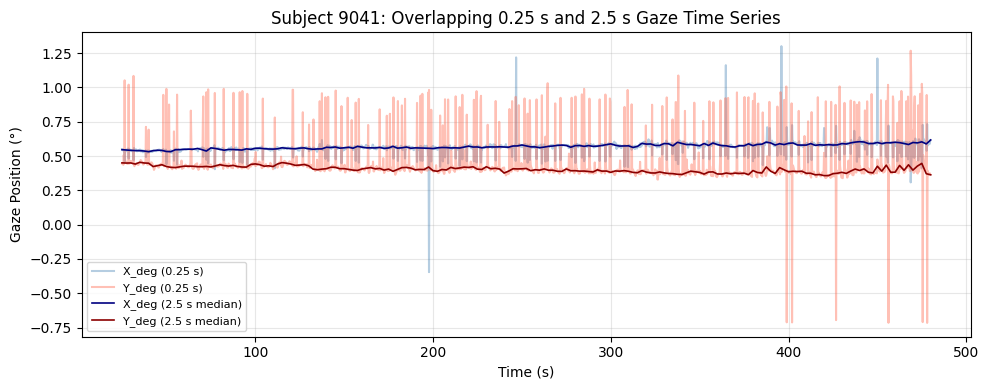

✅ Subject 9041: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9041: processed (shape (182, 10, 2))


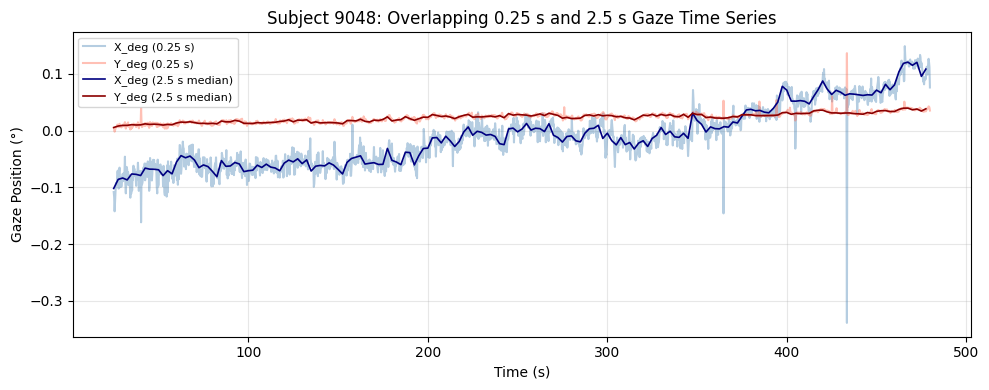

✅ Subject 9048: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9048: processed (shape (182, 10, 2))


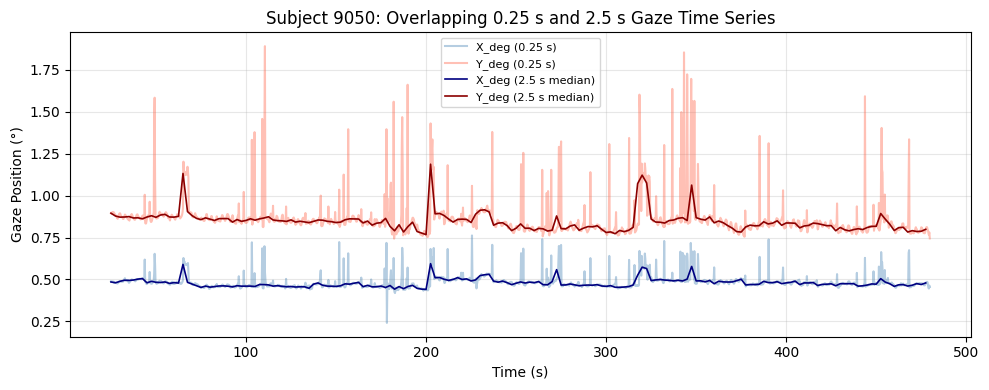

✅ Subject 9050: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9050: processed (shape (182, 10, 2))


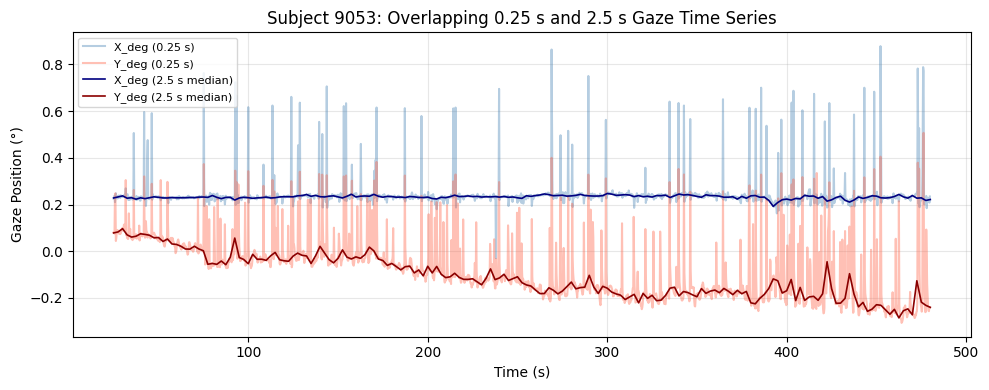

✅ Subject 9053: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9053: processed (shape (182, 10, 2))


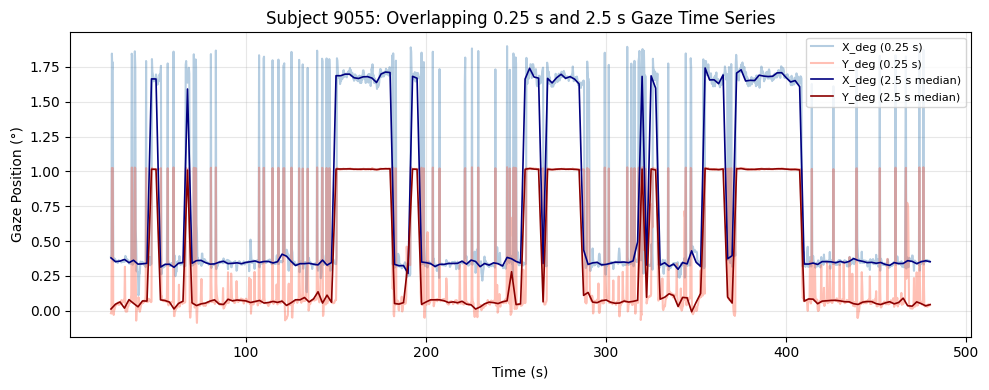

✅ Subject 9055: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9055: processed (shape (182, 10, 2))


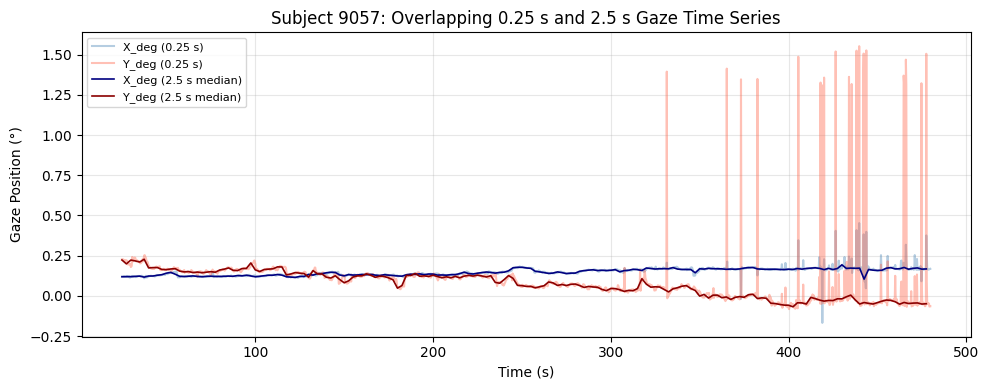

✅ Subject 9057: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9057: processed (shape (182, 10, 2))


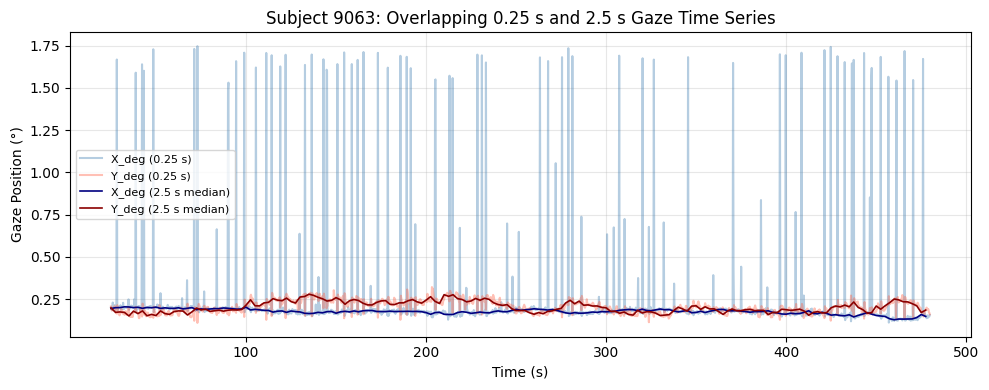

✅ Subject 9063: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9063: processed (shape (182, 10, 2))


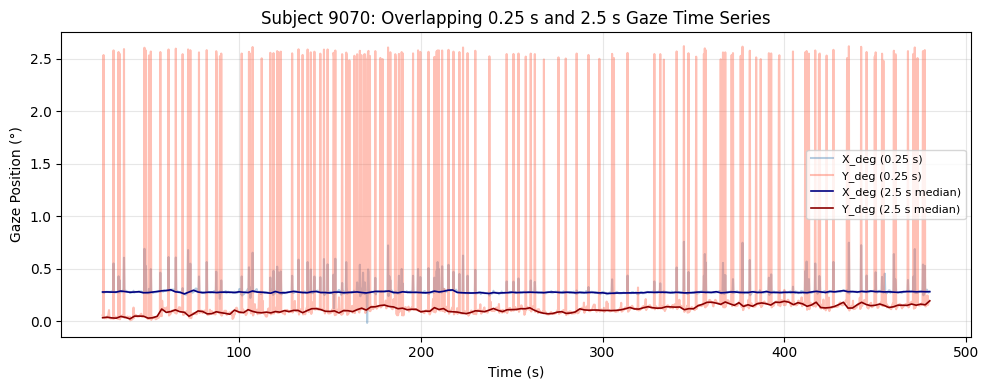

✅ Subject 9070: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9070: processed (shape (182, 10, 2))


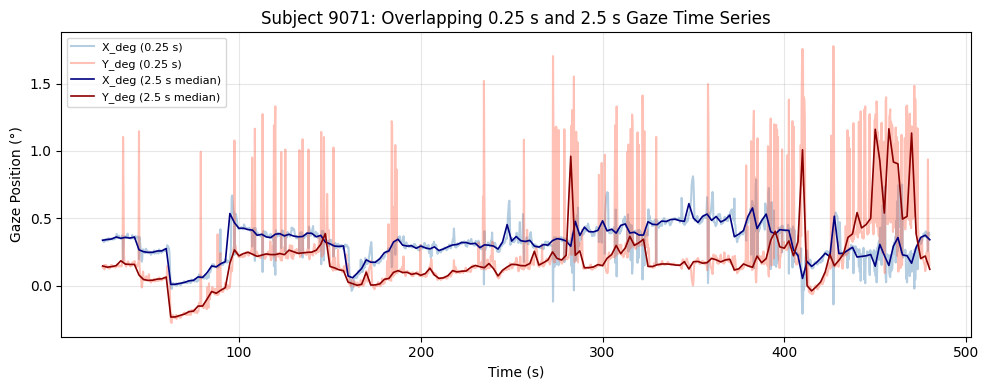

✅ Subject 9071: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9071: processed (shape (182, 10, 2))


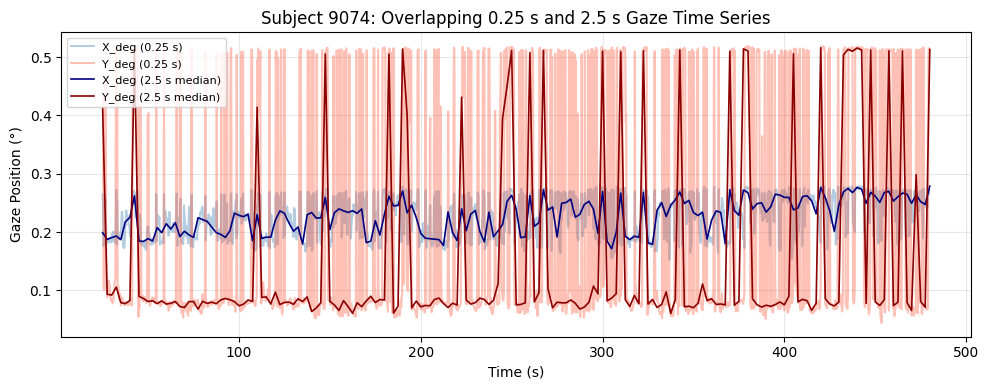

✅ Subject 9074: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9074: processed (shape (182, 10, 2))


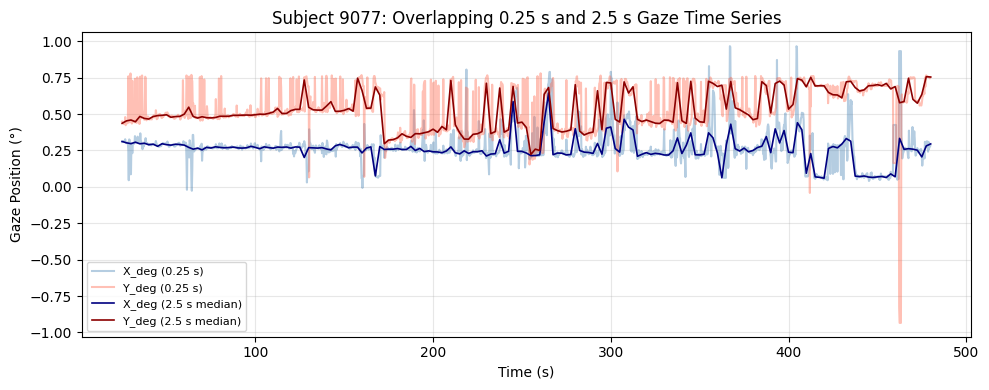

✅ Subject 9077: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9077: processed (shape (182, 10, 2))


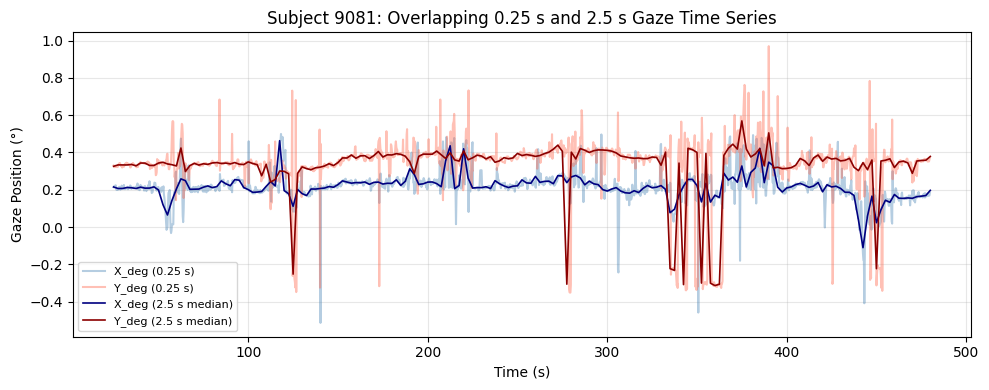

✅ Subject 9081: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9081: processed (shape (182, 10, 2))


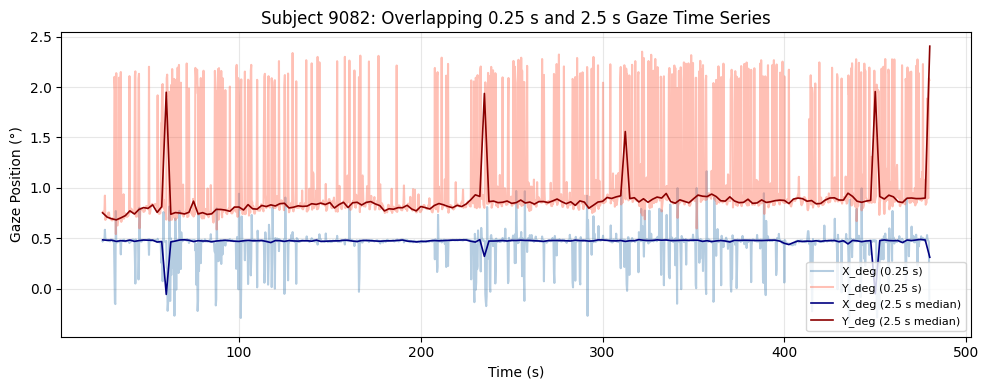

✅ Subject 9082: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9082: processed (shape (182, 10, 2))


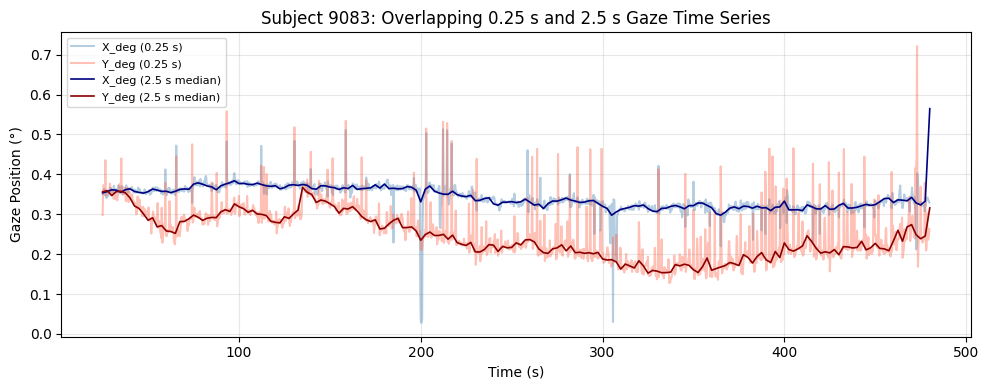

✅ Subject 9083: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9083: processed (shape (182, 10, 2))


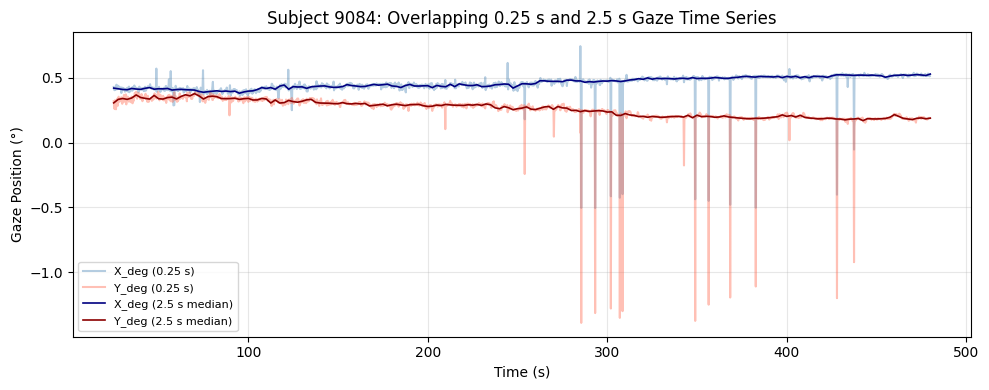

✅ Subject 9084: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9084: processed (shape (182, 10, 2))


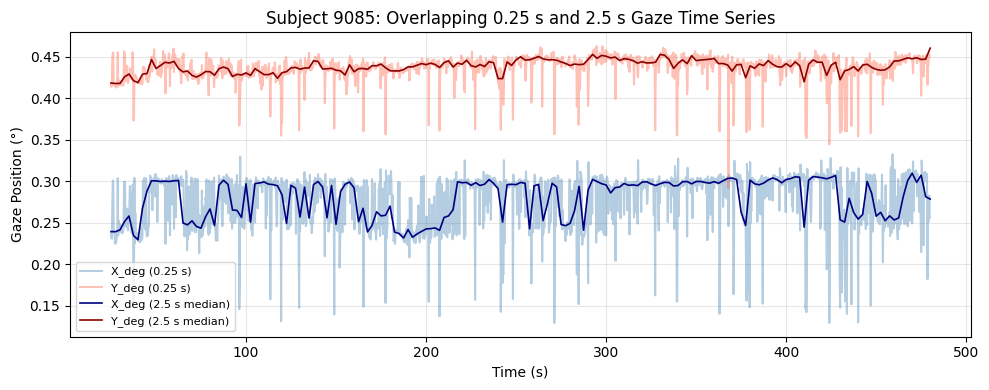

✅ Subject 9085: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9085: processed (shape (182, 10, 2))


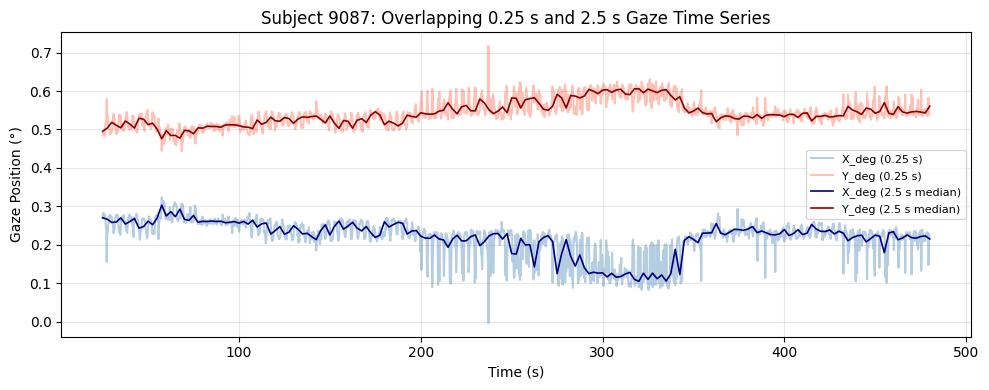

✅ Subject 9087: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9087: processed (shape (182, 10, 2))


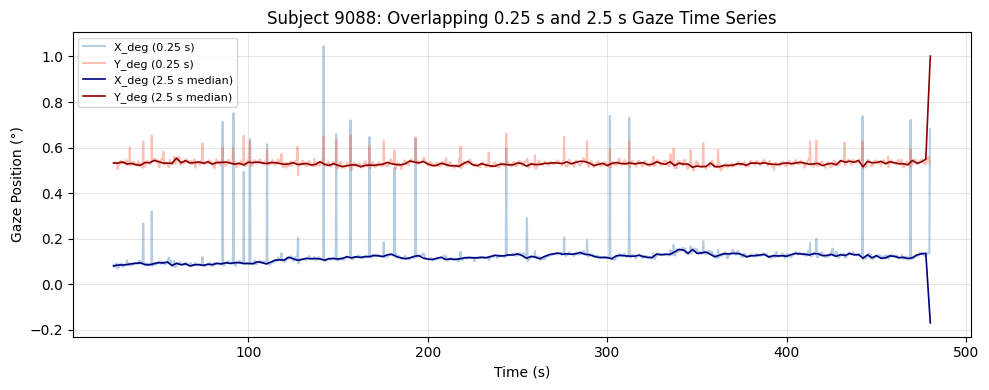

✅ Subject 9088: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9088: processed (shape (182, 10, 2))


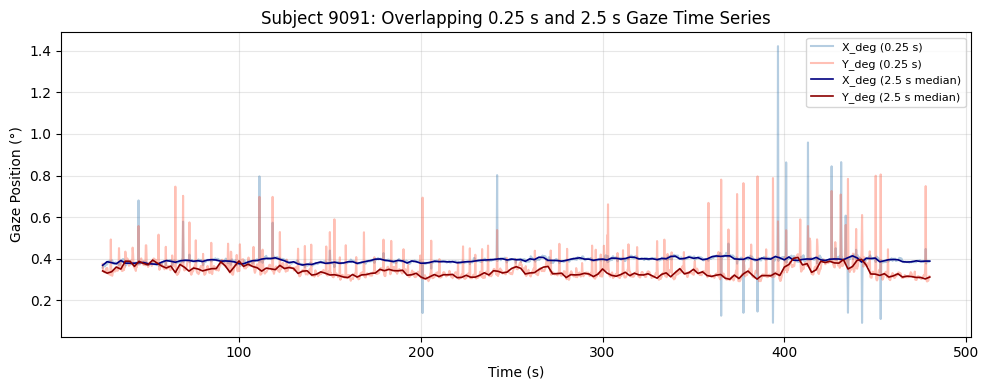

✅ Subject 9091: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9091: processed (shape (182, 10, 2))


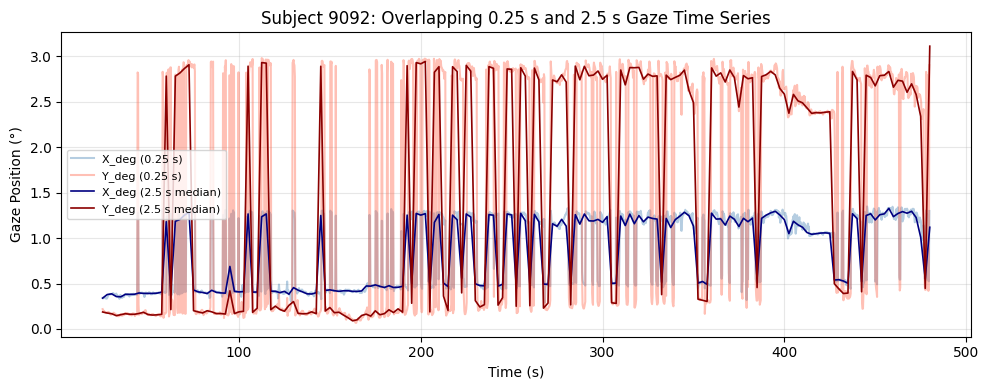

✅ Subject 9092: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9092: processed (shape (182, 10, 2))


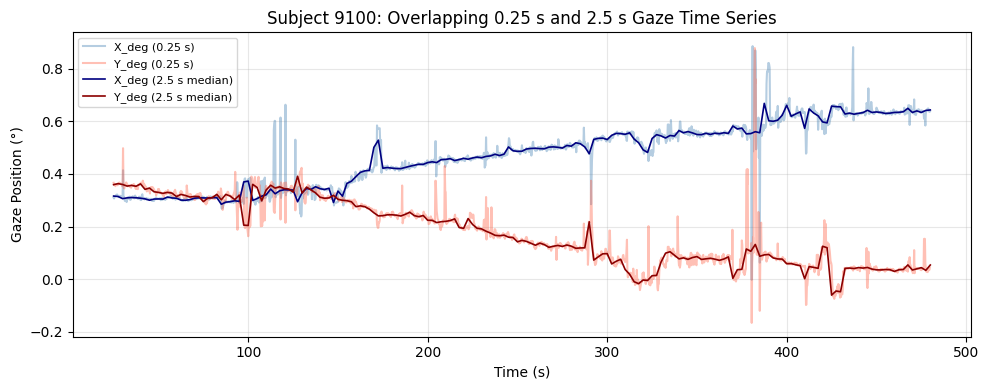

✅ Subject 9100: Downsampled to 182 TRs × 10 sub-TRs × 2 coordinates
✅ 9100: processed (shape (182, 10, 2))

🎯 Finished processing 29 subjects successfully.


{'9001': array([[[0.28126272, 0.52109075],
         [0.28527333, 0.50590858],
         [0.2986229 , 0.5025284 ],
         ...,
         [0.36256285, 0.52956981],
         [0.28000225, 0.53300726],
         [0.29868019, 0.51501789]],
 
        [[0.28395556, 0.51868452],
         [0.28876828, 0.51083563],
         [0.30612844, 0.50888773],
         ...,
         [0.63011358, 0.79527164],
         [0.27977307, 0.52452821],
         [0.2986229 , 0.58875071]],
 
        [[0.31477985, 0.52991355],
         [0.3505885 , 0.54349146],
         [0.35717726, 0.54836116],
         ...,
         [0.29094547, 0.56514724],
         [0.29289347, 0.51306999],
         [0.2845285 , 0.52103346]],
 
        ...,
 
        [[0.26791311, 0.5025284 ],
         [0.79550078, 0.81486293],
         [0.26854335, 0.52779379],
         ...,
         [0.33580672, 0.56881381],
         [0.26676722, 0.55517873],
         [0.26762664, 0.56039215]],
 
        [[0.26711099, 0.53839259],
         [0.28613274, 0.53862176],

In [169]:
batch_downsample_eye_folder(eyetracker_path)

In [65]:
merge_eye_fmri(eye_data_dict, functional_data)

🔍 Found 29 participants with eye data.

👁️‍🧠 Processing participant 9001


/home/CemalKoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/deepmreye/preprocess.py:481: RuntimeWarning: Mean of empty slice
  img_in = (img_in - np.nanmean(img_in, axis=0)) / np.nanstd(img_in, axis=0)
/home/CemalKoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saving eye data (182, 47, 29, 18) and targets (182, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti/9001
Saving eye data (182, 24, 29, 18) and targets (182, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti/9001_left
Saving eye data (182, 23, 29, 18) and targets (182, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti/9001_right
✅ Saved merged data for 9001

👁️‍🧠 Processing participant 9007
Saving eye data (182, 47, 29, 18) and targets (182, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti/9007
Saving eye data (182, 24, 29, 18) and targets (182, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti/9007_left
Saving eye data (182, 23, 29, 18) and targets (182, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti/9007_right
✅ Saved merged data for 9007

👁️‍🧠 Processing participant 9008
Saving eye data (182, 47, 29, 18) and targets (1

/home/CemalKoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/deepmreye/preprocess.py:485: RuntimeWarning: Mean of empty slice
  img_in = np.array([(x - np.nanmean(x)) / np.nanstd(x) for x in img_in])


Saving eye data (182, 47, 29, 18) and targets (182, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti/9100
Saving eye data (182, 24, 29, 18) and targets (182, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti/9100_left
Saving eye data (182, 23, 29, 18) and targets (182, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti/9100_right
✅ Saved merged data for 9100

🎯 All participants processed successfully.


In [161]:
# Define paths to the example dataset
datasets = [functional_data + p for p in os.listdir(functional_data)]

# Load data from one participant to showcase input/output
X, y = data_generator.get_all_subject_data('/mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti/9100.npz')
print("Input: {}, Output: {}".format(X.shape, y.shape))

Input: (182, 47, 29, 18, 1), Output: (182, 10, 2)


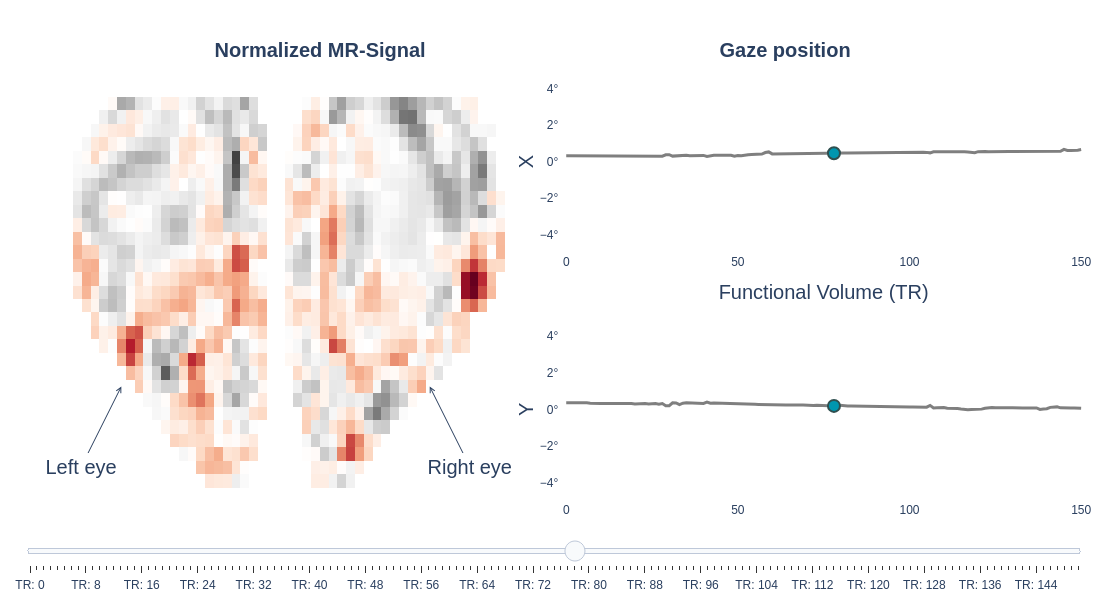

In [162]:
fig = analyse.visualise_input_data(X, y, bg_color="rgb(255,255,255)", ylim=[-5, 5])
fig.show()